# Numerical methods: binomial tree and Monte Carlo

Phase 1 priced European options using the Black-Scholes closed-form formula. 
This notebook introduces two numerical methods that extend option pricing beyond what BSM can handle:

- **Binomial tree (Cox-Ross-Rubinstein)** — prices American options with early exercise, which BSM cannot do
- **Monte Carlo simulation** — simulates thousands of stock price paths under Geometric Brownian Motion and averages the payoffs

Both methods are benchmarked against BSM for European options, and their convergence and accuracy are analyzed.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
sys.path.append('..')

from src.black_scholes import bsm_price
from src.binomial_tree import binomial_tree
from src.monte_carlo import monte_carlo, monte_carlo_antithetic

# Base parameters
S, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.20
bsm_call = bsm_price(S, K, T, r, sigma, "call")
bsm_put  = bsm_price(S, K, T, r, sigma, "put")
print(f"BSM call: ${bsm_call:.4f}")
print(f"BSM put:  ${bsm_put:.4f}")

BSM call: $10.4506
BSM put:  $5.5735


## Part 1: Cox-Ross-Rubinstein binomial tree

### The model

Instead of assuming continuous stock price evolution like BSM, the binomial tree discretizes time into $N$ steps. At each step the stock can move in one of two directions:

$$u = e^{\sigma\sqrt{dt}}, \qquad d = \frac{1}{u}$$

where $dt = T/N$ is the length of each time step. The choice $d = 1/u$ ensures the tree recombines. An up move followed by a down move returns to the same price as a down then up. 

### Deriving u

$u$ is chosen so the tree's variance matches the stock's variance over one time step. Setting $q \approx 0.5$ (valid for small $dt$ since $q \to 0.5$ as $dt \to 0$), the variance of log returns in the tree is $\ln(u)^2$. Matching to $\sigma^2 dt$:

$$\ln(u)^2 = \sigma^2 dt \implies u = e^{\sigma\sqrt{dt}}$$

The $q \approx 0.5$ approximation introduces an error of order $dt$ that vanishes as $N$ increases, which is why the tree converges to BSM in the limit.

### The risk-neutral probability q

$q$ is not the real-world probability of an up move. It is chosen so the expected return on the stock equals the risk-free rate $r$, a no-arbitrage condition:

$$q \cdot Su + (1-q) \cdot Sd = S e^{r \cdot dt}$$

Solving:

$$q = \frac{e^{r \cdot dt} - d}{u - d}$$

### Pricing algorithm

The tree is solved in three steps:

1. Build terminal stock prices at expiry: $S \cdot u^j \cdot d^{N-j}$ for $j = 0, ..., N$
2. Compute option payoffs at each terminal node
3. Work backwards through the tree, discounting expected values at each node:

$$V_i = e^{-r \cdot dt} [q \cdot V_{up} + (1-q) \cdot V_{down}]$$

For **American options**, at each node we also check whether immediate exercise is worth more than holding:

$$V_i = \max(V_{continuation}, V_{intrinsic})$$

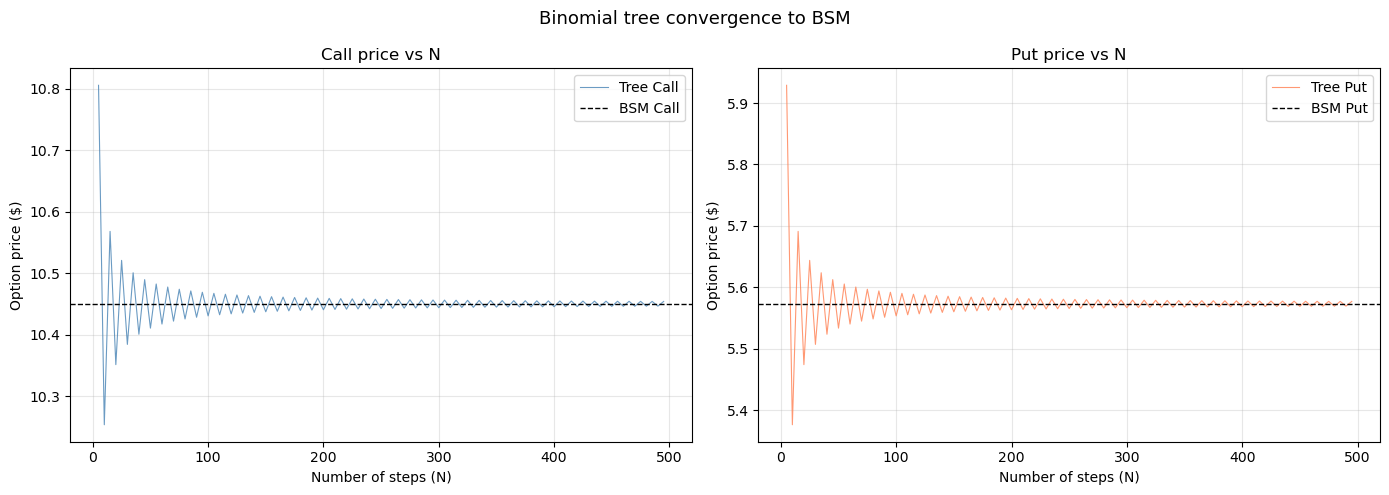

     N |  Tree call |   BSM call |      Error
---------------------------------------------
    10 |    10.2534 |    10.4506 |   0.197175
    50 |    10.4107 |    10.4506 |   0.039892
   100 |    10.4306 |    10.4506 |   0.019972
   200 |    10.4406 |    10.4506 |   0.009992
   500 |    10.4466 |    10.4506 |   0.003998


In [9]:
N_values   = range(5, 500, 5)
tree_calls = [binomial_tree(S, K, T, r, sigma, N, option_type="call") for N in N_values]
tree_puts  = [binomial_tree(S, K, T, r, sigma, N, option_type="put")  for N in N_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Binomial tree convergence to BSM", fontsize=13)

for ax, prices, bsm, label, color in zip(
    axes,
    [tree_calls, tree_puts],
    [bsm_call, bsm_put],
    ["Call", "Put"],
    ["steelblue", "coral"]
):
    ax.plot(N_values, prices, color=color, alpha=0.8, linewidth=0.8, label=f"Tree {label}")
    ax.axhline(bsm, color="black", linestyle="--", linewidth=1, label=f"BSM {label}")
    ax.set_xlabel("Number of steps (N)")
    ax.set_ylabel("Option price ($)")
    ax.set_title(f"{label} price vs N")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("tree_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

# print convergence at key step counts
print(f"{'N':>6} | {'Tree call':>10} | {'BSM call':>10} | {'Error':>10}")
print("-" * 45)
for N in [10, 50, 100, 200, 500]:
    price = binomial_tree(S, K, T, r, sigma, N, option_type="call")
    print(f"{N:>6} | {price:>10.4f} | {bsm_call:>10.4f} | {abs(price-bsm_call):>10.6f}")

### American options 

A European option can only be exercised at expiry. An American option can be exercised at any point before expiry. Since BSM has no closed-form solution for American options, numerical methods like the binomial tree are required.

It can be shown analytically that early exercise of an American call on a non-dividend-paying stock is never optimal. The intuition is that holding the call preserves optionality and earns interest on the strike you haven't paid yet. Therefore American call = European call for non-dividend stocks.

Early exercise of a put can be optimal. If the stock falls far enough, the interest earned on the proceeds of early exercise outweighs the lost optionality. Therefore American put > European put, and the difference is the early exercise premium.

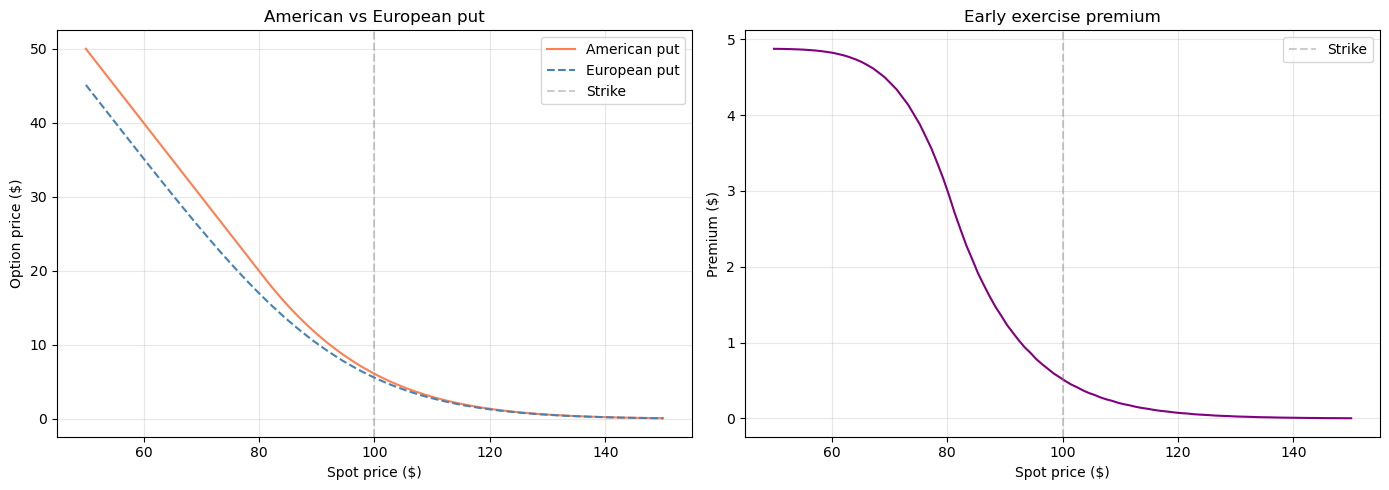

American call: $10.4406
European call: $10.4406


In [10]:
N = 200
spot_range = np.linspace(50, 150, 100)

european_puts = [binomial_tree(s, K, T, r, sigma, N, option_type="put", american=False) 
                 for s in spot_range]
american_puts = [binomial_tree(s, K, T, r, sigma, N, option_type="put", american=True)  
                 for s in spot_range]
early_exercise_premium = np.array(american_puts) - np.array(european_puts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(spot_range, american_puts, label="American put", color="coral")
axes[0].plot(spot_range, european_puts, label="European put", color="steelblue", 
             linestyle="--")
axes[0].axvline(K, color="gray", linestyle="--", alpha=0.4, label="Strike")
axes[0].set_xlabel("Spot price ($)")
axes[0].set_ylabel("Option price ($)")
axes[0].set_title("American vs European put")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(spot_range, early_exercise_premium, color="purple")
axes[1].axvline(K, color="gray", linestyle="--", alpha=0.4, label="Strike")
axes[1].set_xlabel("Spot price ($)")
axes[1].set_ylabel("Premium ($)")
axes[1].set_title("Early exercise premium")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("american_vs_european.png", dpi=150, bbox_inches="tight")
plt.show()

# verify American call = European call
amer_call = binomial_tree(S, K, T, r, sigma, N, option_type="call", american=True)
euro_call = binomial_tree(S, K, T, r, sigma, N, option_type="call", american=False)
print(f"American call: ${amer_call:.4f}")
print(f"European call: ${euro_call:.4f}")

## Part 2: Monte Carlo simulation

### The core idea

Monte Carlo prices options by simulation rather than formula:

1. Simulate $M$ possible stock price paths under risk-neutral GBM
2. Compute the option payoff at the end of each path
3. Average the payoffs and discount back to today

The law of large numbers guarantees the average converges to the true expected payoff as $M \to \infty$.

### Simulating stock prices

Stock prices follow Geometric Brownian Motion. In discrete time, the log return over one step is:

$$\ln\left(\frac{S_{t+dt}}{S_t}\right) = \left(r - \frac{\sigma^2}{2}\right)dt + \sigma\sqrt{dt} \cdot Z, \qquad Z \sim N(0,1)$$

We simulate in log space rather than price space because:
- Stock prices can't go negative, but normal distributions can.
- The $\frac{\sigma^2}{2}$ correction (Ito's lemma) ensures the expected 
  return equals $r$, not $r + \frac{\sigma^2}{2}$

### Uncertainty quantification

Unlike BSM and the binomial tree, Monte Carlo is a statistical estimator. Every price comes with inherent randomness that decreases as $\frac{1}{\sqrt{M}}$. 
The 95% confidence interval is:

$$\text{price} \pm 1.96 \times \frac{\sigma_{payoffs}}{\sqrt{M}}$$

To halve the error you need four times as many simulations. 

### Antithetic variates — variance reduction

For every random path $Z$ simulated, also simulate $-Z$. Since $Z \sim N(0,1)$, 
$-Z$ has the same distribution and is an equally valid simulation, but it is 
perfectly negatively correlated with its pair.

The antithetic paths are genuinely random, but slightly correlated. However for vanilla option pricing, only the average payoff across paths 
matters, not the joint distribution between paths. Negative correlation between pairs causes high payoffs to be offset by low payoffs, reducing variance.

Mathematically, for paired paths $X$ and $-X$:

$$\text{Var}\left(\frac{X + (-X)}{2}\right) = \frac{\text{Var}(X) + \text{Var}(-X) + 2\text{Cov}(X,-X)}{4}$$

Since $\text{Cov}(X, -X) < 0$, the variance is strictly smaller than plain Monte Carlo with the same number of paths.


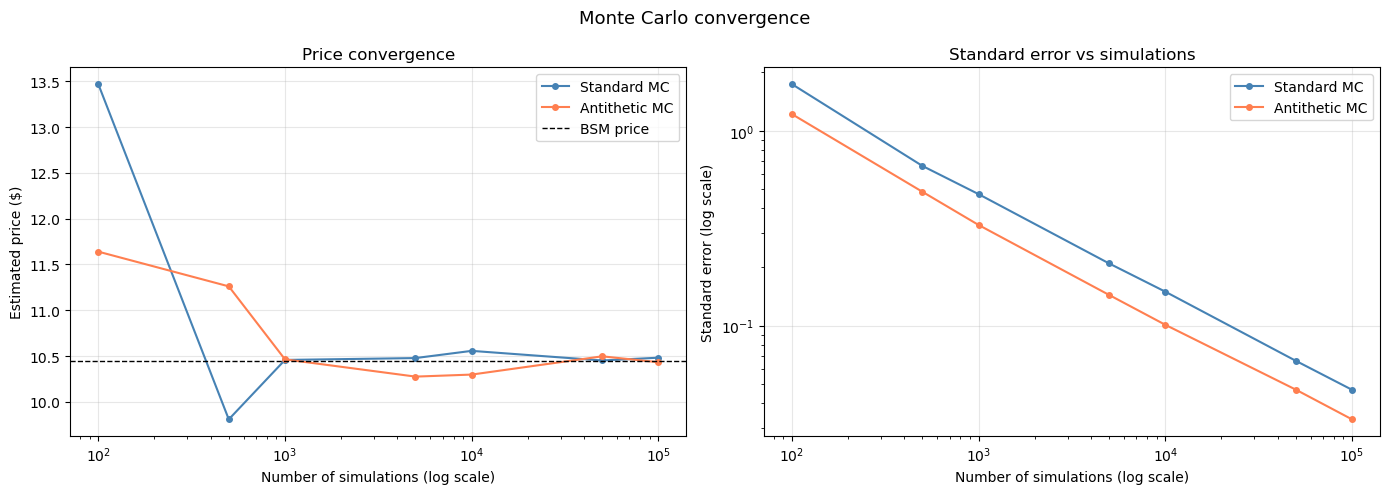


 Simulations |   MC price | Anti price |    MC SE |  Anti SE | SE reduction
------------------------------------------------------------------------
         100 |    13.4682 |    11.6402 |   1.7344 |   1.2171 |        29.8%
         500 |     9.8101 |    11.2612 |   0.6599 |   0.4862 |        26.3%
        1000 |    10.4585 |    10.4647 |   0.4728 |   0.3285 |        30.5%
        5000 |    10.4789 |    10.2766 |   0.2086 |   0.1438 |        31.1%
       10000 |    10.5575 |    10.2988 |   0.1494 |   0.1010 |        32.4%
       50000 |    10.4526 |    10.4979 |   0.0660 |   0.0470 |        28.9%
      100000 |    10.4829 |    10.4333 |   0.0469 |   0.0331 |        29.5%


In [11]:
simulation_counts = [100, 500, 1000, 5000, 10000, 50000, 100000]

mc_prices      = []
mc_errors      = []
mc_anti_prices = []
mc_anti_errors = []

for n in simulation_counts:
    mc      = monte_carlo(S, K, T, r, sigma, n_simulations=n)
    mc_anti = monte_carlo_antithetic(S, K, T, r, sigma, n_simulations=n)
    mc_prices.append(mc["price"])
    mc_errors.append(mc["std_error"])
    mc_anti_prices.append(mc_anti["price"])
    mc_anti_errors.append(mc_anti["std_error"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Monte Carlo convergence", fontsize=13)

# price convergence
axes[0].semilogx(simulation_counts, mc_prices, 
                  color="steelblue", marker="o", markersize=4, label="Standard MC")
axes[0].semilogx(simulation_counts, mc_anti_prices, 
                  color="coral", marker="o", markersize=4, label="Antithetic MC")
axes[0].axhline(bsm_call, color="black", linestyle="--", linewidth=1, label="BSM price")
axes[0].set_xlabel("Number of simulations (log scale)")
axes[0].set_ylabel("Estimated price ($)")
axes[0].set_title("Price convergence")
axes[0].legend()
axes[0].grid(alpha=0.3)

# standard error comparison
axes[1].loglog(simulation_counts, mc_errors, 
                color="steelblue", marker="o", markersize=4, label="Standard MC")
axes[1].loglog(simulation_counts, mc_anti_errors, 
                color="coral", marker="o", markersize=4, label="Antithetic MC")
axes[1].set_xlabel("Number of simulations (log scale)")
axes[1].set_ylabel("Standard error (log scale)")
axes[1].set_title("Standard error vs simulations")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mc_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'Simulations':>12} | {'MC price':>10} | {'Anti price':>10} | "
      f"{'MC SE':>8} | {'Anti SE':>8} | {'SE reduction':>12}")
print("-" * 72)
for i, n in enumerate(simulation_counts):
    reduction = (1 - mc_anti_errors[i] / mc_errors[i]) * 100
    print(f"{n:>12} | {mc_prices[i]:>10.4f} | {mc_anti_prices[i]:>10.4f} | "
          f"{mc_errors[i]:>8.4f} | {mc_anti_errors[i]:>8.4f} | {reduction:>11.1f}%")

In [12]:
print(f"{'n':>8} | {'MC SE':>8} | {'Anti SE':>8} | {'reduction':>10}")
print("-" * 45)
for i, n in enumerate(simulation_counts):
    reduction = (1 - mc_anti_errors[i] / mc_errors[i]) * 100
    print(f"{n:>8} | {mc_errors[i]:>8.4f} | {mc_anti_errors[i]:>8.4f} | {reduction:>9.1f}%")

       n |    MC SE |  Anti SE |  reduction
---------------------------------------------
     100 |   1.7344 |   1.2171 |      29.8%
     500 |   0.6599 |   0.4862 |      26.3%
    1000 |   0.4728 |   0.3285 |      30.5%
    5000 |   0.2086 |   0.1438 |      31.1%
   10000 |   0.1494 |   0.1010 |      32.4%
   50000 |   0.0660 |   0.0470 |      28.9%
  100000 |   0.0469 |   0.0331 |      29.5%


In [13]:
from src.monte_carlo import monte_carlo_antithetic
import numpy as np

rng = np.random.default_rng(42)
dt  = T / 252
n   = 10000

Z        = rng.standard_normal((n // 2, 252))
Z_paired = np.vstack([Z, -Z])

log_returns     = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z_paired
terminal_prices = S * np.exp(np.cumsum(log_returns, axis=1)[:, -1])
payoffs         = np.maximum(terminal_prices - K, 0) * np.exp(-r * T)

payoffs_Z  = payoffs[:n//2]   # original paths
payoffs_nZ = payoffs[n//2:]   # antithetic paths

correlation = np.corrcoef(payoffs_Z, payoffs_nZ)[0, 1]
print(f"Correlation between Z and -Z payoffs: {correlation:.4f}")
print(f"Var(Z payoffs):           {payoffs_Z.var():.4f}")
print(f"Var(-Z payoffs):          {payoffs_nZ.var():.4f}")
print(f"Var(pair averages):       {((payoffs_Z + payoffs_nZ)/2).var():.4f}")
print(f"Expected var reduction:   {(1 - ((payoffs_Z + payoffs_nZ)/2).var() / payoffs_Z.var()) * 100:.1f}%")

Correlation between Z and -Z payoffs: -0.5085
Var(Z payoffs):           217.4832
Var(-Z payoffs):          197.4102
Var(pair averages):       51.0411
Expected var reduction:   76.5%


## Part 3: benchmarking all three methods

The three methods make different tradeoffs between speed and accuracy.

In [14]:
methods = {
    "BSM (exact)": lambda: bsm_price(S, K, T, r, sigma, "call"),
    "Binomial N=100":  lambda: binomial_tree(S, K, T, r, sigma, 100),
    "Binomial N=500":  lambda: binomial_tree(S, K, T, r, sigma, 500),
    "Monte Carlo 10k": lambda: monte_carlo(S, K, T, r, sigma, 10000)["price"],
    "Monte Carlo 100k":lambda: monte_carlo(S, K, T, r, sigma, 100000)["price"],
    "Antithetic 10k":  lambda: monte_carlo_antithetic(S, K, T, r, sigma, 10000)["price"],
}

print(f"{'Method':<22} | {'Price':>8} | {'Error vs BSM':>12} | {'Time (ms)':>10}")
print("-" * 62)

for name, fn in methods.items():
    start = time.perf_counter()
    price = fn()
    elapsed = (time.perf_counter() - start) * 1000
    error = abs(price - bsm_call)
    print(f"{name:<22} | {price:>8.4f} | {error:>12.6f} | {elapsed:>10.2f}")

Method                 |    Price | Error vs BSM |  Time (ms)
--------------------------------------------------------------
BSM (exact)            |  10.4506 |     0.000000 |       0.20
Binomial N=100         |  10.4306 |     0.019972 |       0.27
Binomial N=500         |  10.4466 |     0.003998 |       1.48
Monte Carlo 10k        |  10.5575 |     0.106899 |      35.11
Monte Carlo 100k       |  10.4829 |     0.032275 |     373.68
Antithetic 10k         |  10.2988 |     0.151827 |      26.39


## Observations

### Binomial tree convergence

The tree price oscillates around the BSM price with decreasing amplitude as N 
increases, rather than converging monotonically. This is a known property of the 
CRR model. The discrete strike interacts with the tree structure differently 
depending on whether N is odd or even, causing the price to approach BSM from 
alternating sides. By N=300 the oscillations become very small.

### American vs European puts

The American put trades strictly above the European put across the entire spot 
range, including significantly above the strike price. At S=105 the early exercise 
premium is $0.32, and at S=110 it is $0.20, both well above zero despite the 
option being out of the money today.

**American calls**

On the other hand, the early exercise premium for American calls on non-dividend paying stocks is 
exactly zero. This follows from a no-arbitrage argument: 
since `K*e^(-rT) < K`, put-call parity implies the call is always worth strictly 
more than its intrinsic value `S - K`. Exercising early gives you the intrinsic 
value but destroys the remaining time value and forgoes interest on the strike. 

### Monte Carlo convergence

Both standard and antithetic MC converge to the BSM price as simulations increase, 
but with considerable noise at low simulation counts. At n=100 the standard MC 
estimate is $13.49, nearly $3 above the BSM price. This is expected given the 
standard error of $1.73 at that level.

**Antithetic variance reduction**

After correctly computing standard error across pair averages rather than 
individual payoffs, antithetic variates achieves a consistent ~30% reduction 
in standard error across all simulation counts.

The consistency of ~30% across every simulation count confirms this is structural 
variance reduction, not noise. The correlation between paired payoffs Z and -Z is 
-0.51, which is the negative correlation that drives the effect. Every path that 
produces a high payoff is paired with one that produces a low payoff, stabilizing 
the average.

### Method comparison

| Method | Price accuracy | Speed |
|--------|---------------|-------|
| BSM | Exact | Instant |
| Binomial N=100 | High | Fast |
| Binomial N=500 | Very high | Moderate |
| Monte Carlo 10k | Statistical (SE~$0.15) | Slow |
| Monte Carlo 100k | Statistical (SE~$0.05) | Very slow |
| Antithetic 10k | Statistical (SE~$0.10) | Slow |

### Key takeaways

- The binomial tree is the right tool when you need American option pricing with 
  high accuracy and controllable error, just increase N
- Monte Carlo is slower and less accurate for vanilla options but is the only 
  practical method for path-dependent or multi-asset options where BSM and the 
  tree don't generalize
- Both numerical methods assume constant volatility, just like in the BSM world